# Dataset Distribution Analysis
This section explores the statistical distribution of the primary variables of the engineered dataset, with a specific focus on the target variable (totalAssignments) and how it is conditioned by the other ones. In the scripts below the following variables are analyzed:
- totalAssignments (and how it's conditioned by the day of week),
- totalTT,
- totalTherapieDemand,
- totalPatients,
- numOverWorked and numUnderWorked operators

All the analysis of these variables are available in the chapter 4 of the paper.

<Axes: title={'center': 'Distribuzione delle Terapie Correttamente Schedulate'}, xlabel='Numero di Assegnamenti', ylabel='Frequenza nelle pianificazioni'>

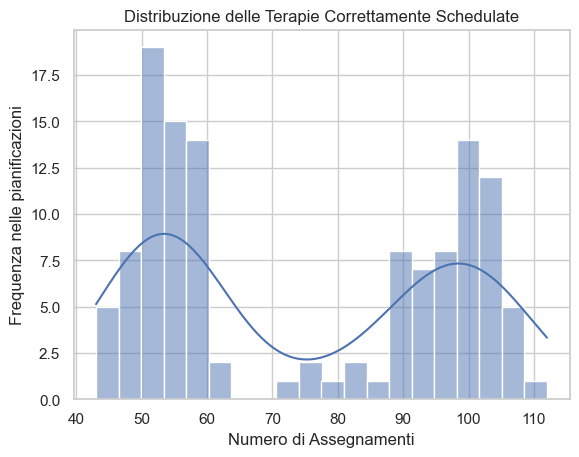

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
from sympy.printing.pretty.pretty_symbology import line_width

sns.set_theme(style="whitegrid")

import pandas as pd

df = pd.read_csv("./data/cleaned_dataset.csv")

plt.title("Distribuzione delle Terapie Correttamente Schedulate")
plt.xlabel("Numero di Assegnamenti")
plt.ylabel("Frequenza nelle pianificazioni")
sns.histplot(data=df['totalAssignments'], bins=20, kde=True)

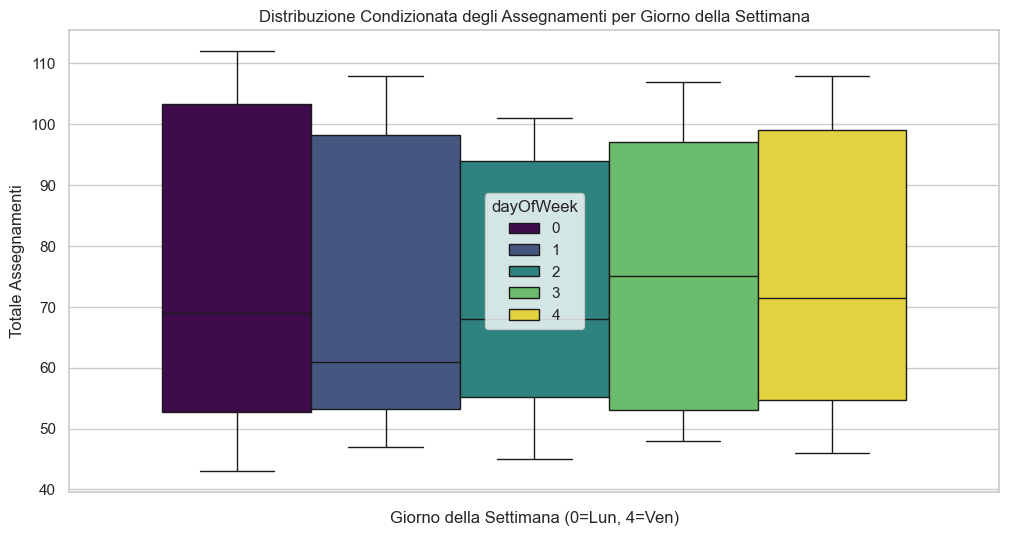

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

sns.boxplot(data=df, hue='dayOfWeek', y='totalAssignments', palette='viridis')

plt.title('Distribuzione Condizionata degli Assegnamenti per Giorno della Settimana')
plt.xlabel('Giorno della Settimana (0=Lun, 4=Ven)')
plt.ylabel('Totale Assegnamenti')
plt.show()

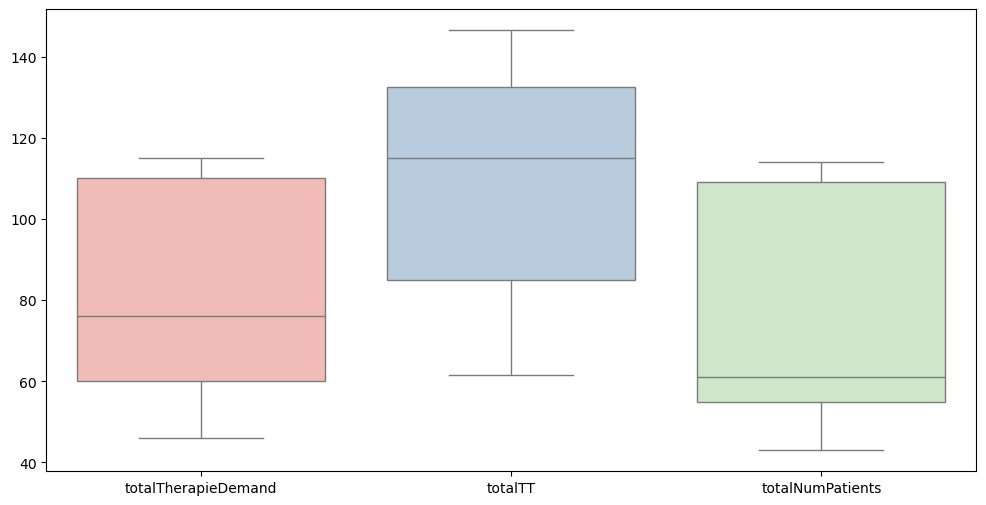

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

plt.figure(figsize=(12, 6))

df = pd.read_csv("./data/cleaned_dataset.csv")

sns.boxplot(data=df[['totalTherapieDemand', 'totalTT', 'totalNumPatients']], palette="Pastel1")
plt.xlabel('Volumi di pianificazioni')
plt.ylabel('Valori Assoluti')

plt.show()

# Correlation Analysis
This section shows a statistical method I used in order to evaluate the strenght of the reletionships between features using the Pearson coefficient.
First I observed the correlation between the target variable and all the other features.
Secondly, I started classifying too correlated features with each other (excluding correlation with the target) through the Correlation Matrix plotted by a heatmap.

Text(0.5, 1.0, 'Correlazione con coefficiente di Pearson con la variabile target')

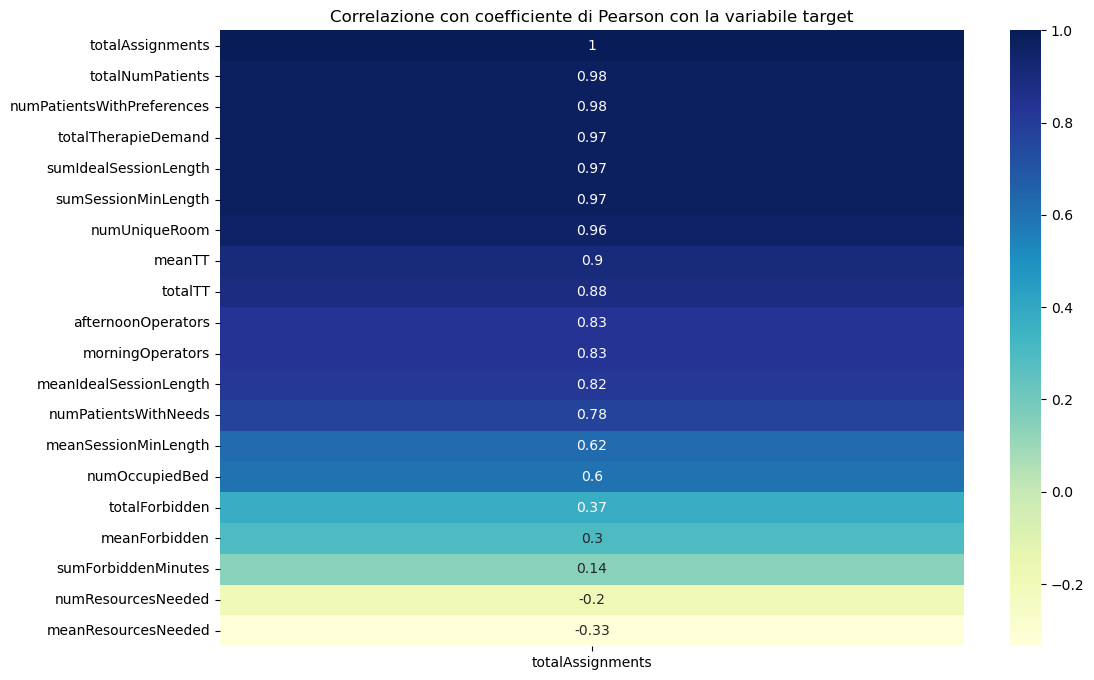

In [6]:
import seaborn as sns
import pandas as pd

df = pd.read_csv("./data/cleaned_dataset.csv", )

df.drop(columns=["planningDate_dt", "Unnamed: 0", "dayOfWeek", "month"], inplace=True)

corr_matrix = df.corr()[['totalAssignments']].sort_values(ascending=False, by=['totalAssignments'])

plt.figure(figsize=(12, 8))
sns.heatmap(data=corr_matrix, annot=True, cmap="YlGnBu", xticklabels=True, yticklabels=True)
plt.title("Correlazione con coefficiente di Pearson con la variabile target")

Text(0.5, 1.0, 'Matrice di Correlazione con coefficiente di Pearson')

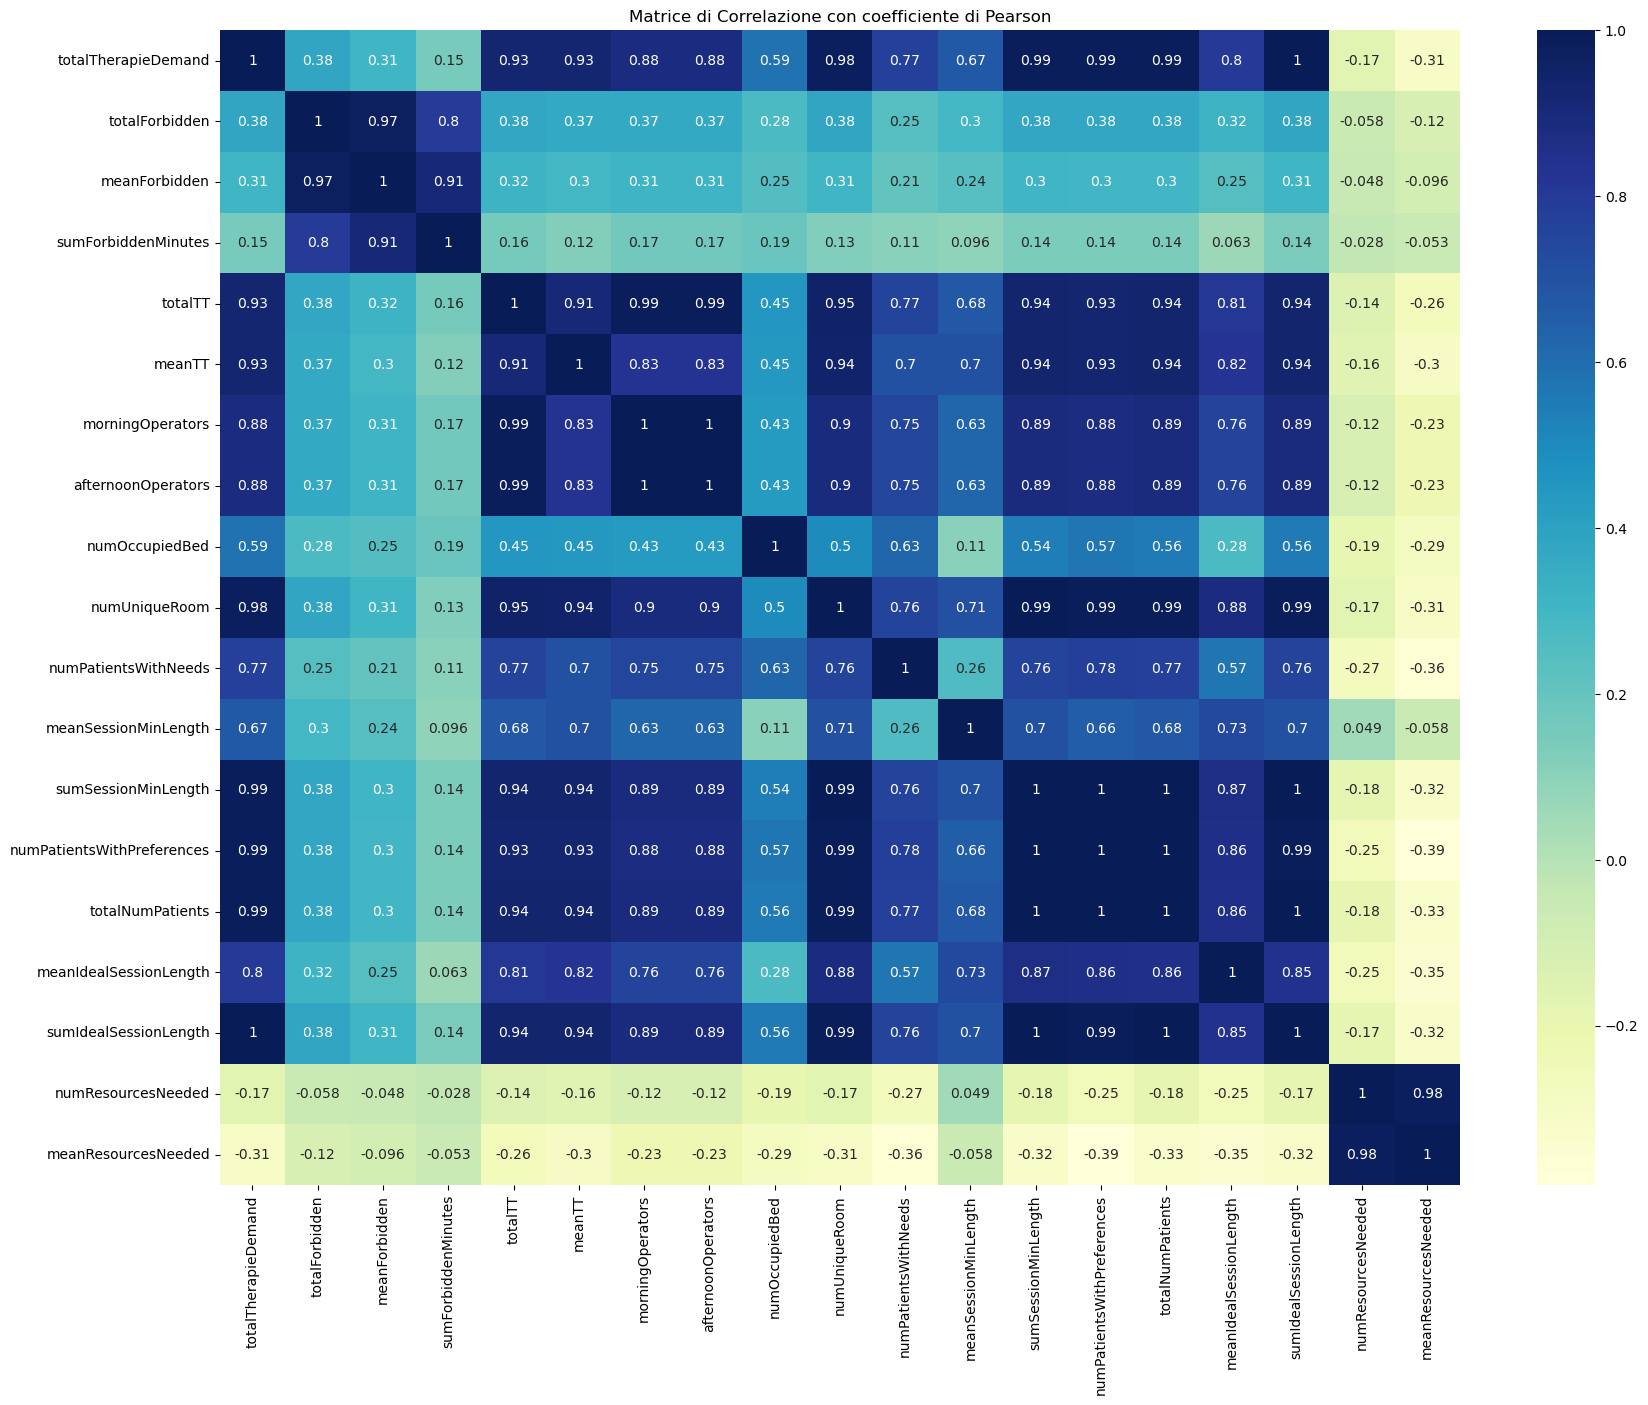

In [1]:
import seaborn as sns
import pandas as pd

df = pd.read_csv("./data/cleaned_dataset.csv", )

df.drop(columns=["planningDate_dt", "Unnamed: 0", "month", "totalAssignments", "dayOfWeek"], inplace=True)

plt.figure(figsize=(20, 15))
sns.heatmap(data=df.corr(), annot=True, cmap="YlGnBu", xticklabels=True, yticklabels=True)
plt.title("Matrice di Correlazione con coefficiente di Pearson")

Columns to be dropped: {'meanForbidden', 'morningOperators', 'totalTherapieDemand', 'sumSessionMinLength', 'sumIdealSessionLength', 'numResourcesNeeded', 'meanTT', 'numUniqueRoom', 'numPatientsWithPreferences'}


Text(0.5, 1.0, 'Matrice di Correlazione con coefficiente di Pearson')

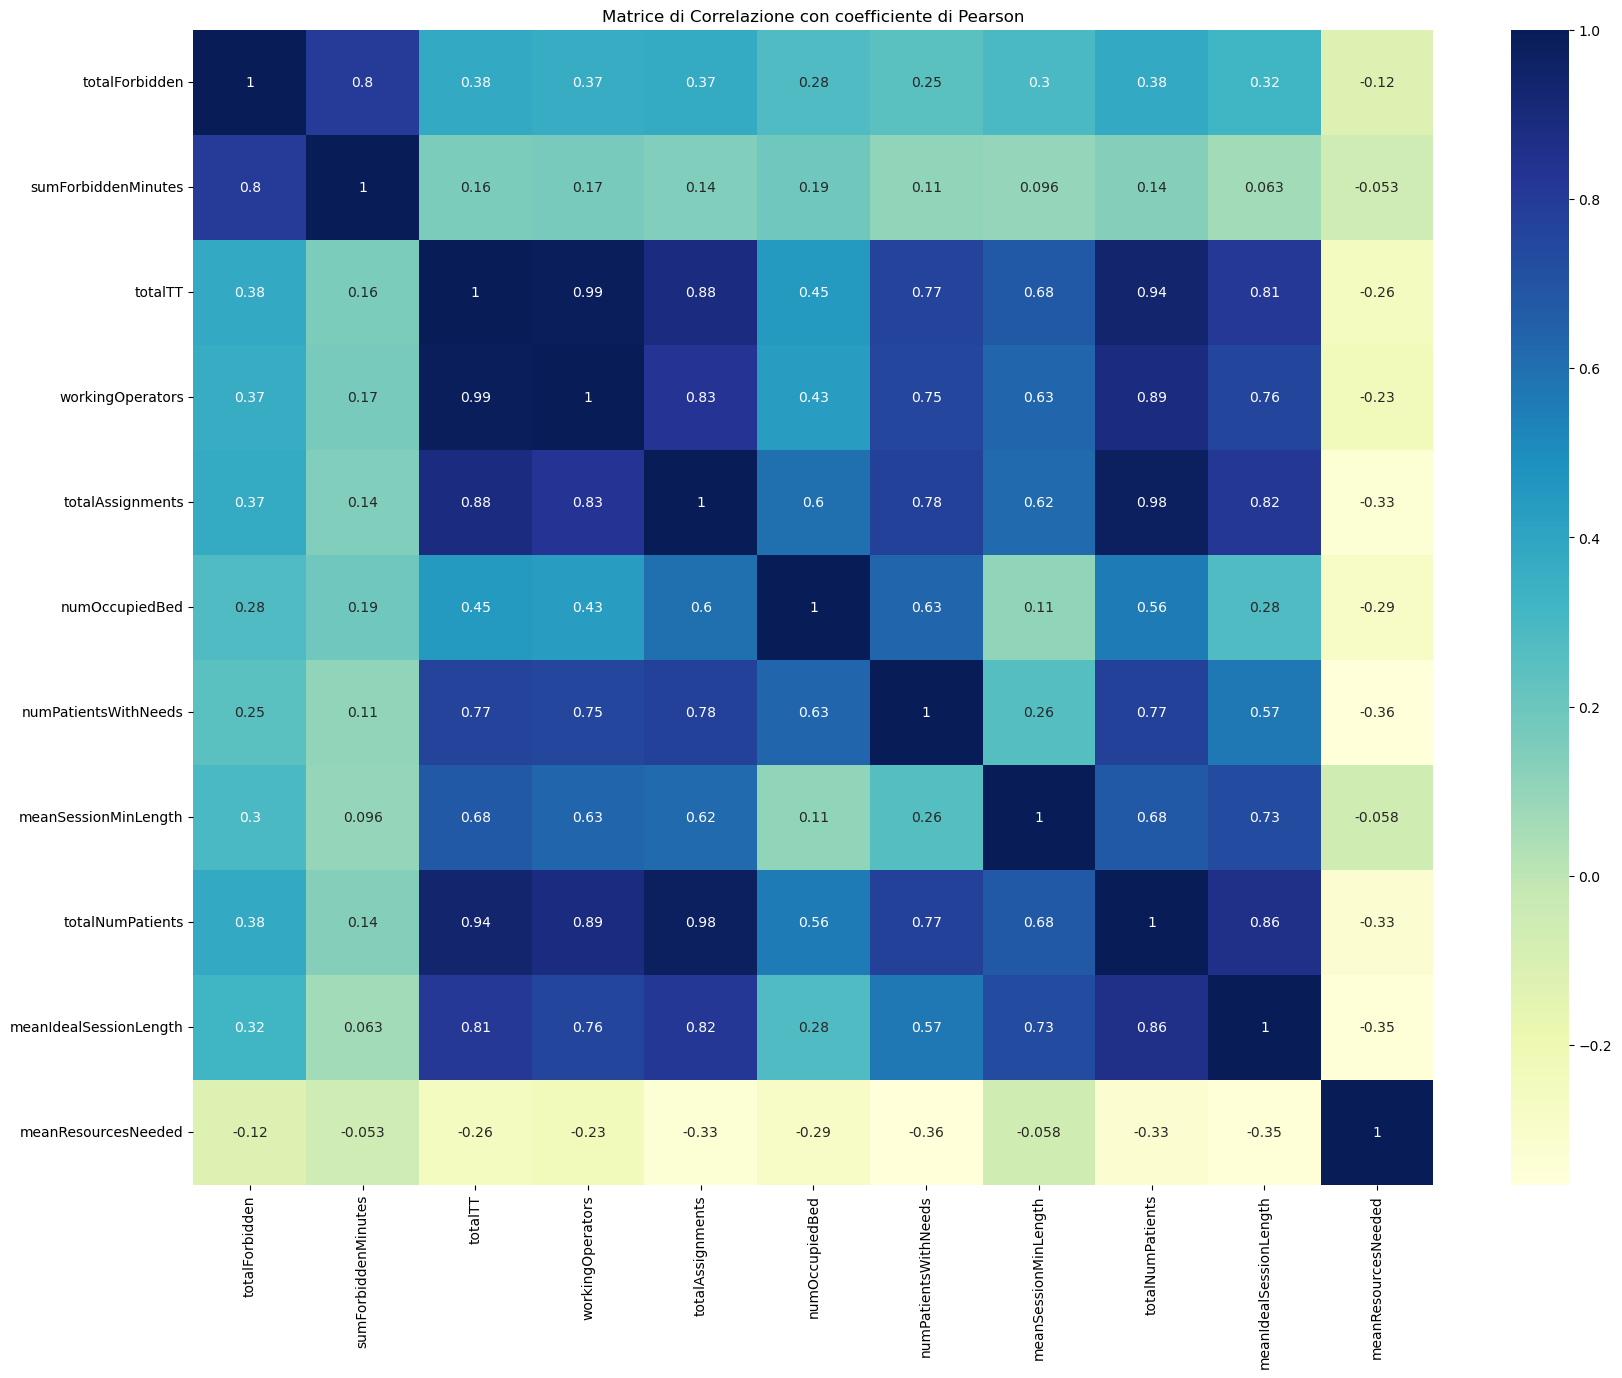

In [4]:
import seaborn as sns
import pandas as pd

df = pd.read_csv("./data/cleaned_dataset.csv")
df_copy = df.copy()

df_copy.drop(columns=["planningDate_dt", "Unnamed: 0", "month", "dayOfWeek"], inplace=True)
df.drop(columns=["planningDate_dt", "Unnamed: 0", "month", "dayOfWeek"], inplace=True)
corr_target = df_copy.corr()['totalAssignments'].abs().sort_values(ascending=False)

df_copy.drop(columns=["totalAssignments"], inplace=True)

corr_matrix = df_copy.corr().abs()

columns_to_be_dropped = set()
columns = corr_matrix.columns

for i in range(len(columns)):
    col_a = columns[i]

    if col_a in columns_to_be_dropped:
        continue

    for j in range(i + 1, len(columns)):
        col_b = columns[j]

        if corr_matrix.loc[col_a, col_b] >= 0.90:

            # correlation compared to the target variable
            corr_of_a = corr_target.loc[col_a]
            corr_of_b = corr_target.loc[col_b]

            if corr_of_a > corr_of_b:
                columns_to_be_dropped.add(col_b)
            else:
                columns_to_be_dropped.add(col_a)
                break

if 'totalTT' in columns_to_be_dropped:
    columns_to_be_dropped.remove('totalTT')

print(f"Columns to be dropped: {columns_to_be_dropped}")
df.drop(columns=columns_to_be_dropped, inplace=True)
df.rename(columns={"afternoonOperators": "workingOperators"}, inplace=True)
df.to_csv("./data/final_dataset.csv", index=False)

plt.figure(figsize=(20, 15))
sns.heatmap(data=df.corr(), annot=True, cmap="YlGnBu", xticklabels=True, yticklabels=True)
plt.title("Matrice di Correlazione con coefficiente di Pearson")